# Predictive Analytics Benchmark — Hotel Bookings Cancellation

---
## Task 1

### 1. Plan

Steps to be executed in Task 1:

1. Read `dataset_description.pdf` and record variable definitions, data sources, temporal scope, and any caveats stated by the authors.
2. Load `hotel_bookings.csv` and verify shape, dtypes, and column names against the documentation.
3. Inspect every variable: its meaning (from docs), observed range, and any inconsistency with the documented description.
4. Quantify missing values; distinguish true nulls from documented "NULL" categories.
5. Detect data quality issues: impossible numeric values, duplicate rows, zero-night bookings, inconsistent categorical levels.
6. Flag leakage and methodological risk variables, citing documentation evidence.
7. Produce a structured preprocessing plan with justification for each decision.

**Source convention used throughout:**
- *[DOC]* = interpretation derived from the documentation
- *[OBS]* = interpretation inferred from observed data patterns

### 2. Risks

| # | Risk category | Specific risk | Notes |
|---|---------------|---------------|-------|
| 1 | **Data leakage** | `reservation_status` directly encodes the cancellation outcome | *[DOC]* Authors confirm it is the "last status" of a booking — a post-outcome label |
| 2 | **Data leakage** | `reservation_status_date` is the date the final status was set | *[DOC]* Post-outcome timestamp, always after cancellation or check-out |
| 3 | **Data leakage** | `deposit_type` is computed from transactions recorded up to the arrival **or cancellation** date | *[DOC]* Table 1 footnote: "payments identified… before the booking's arrival or cancellation date" — cancellation date is post-outcome |
| 4 | **Data leakage** | `assigned_room_type` is the room actually given at check-in | *[DOC]* Assigned at check-in; may differ from reserved — not known at booking time for cancelled bookings |
| 5 | **Data leakage** | `booking_changes` is counted up to "check-in or cancellation" | *[DOC]* Changes after the prediction point (day prior to arrival) are post-outcome |
| 6 | **Distributional bias** | `country` may not be correctly known until check-in | *[DOC]* "hotels may not know the correct nationality of the customer until the moment of check-in" |
| 7 | **Data quality** | `adr` contains negative values | *[OBS]* H1 min = −6.38 per documentation; physically impossible as a rate |
| 8 | **Data quality** | Extreme outliers in `adr` (H2 max = 5400) and `adults` (max = 55) | *[OBS]* Far exceed plausible hotel values |
| 9 | **Data quality** | Zero-night bookings (`stays_in_weekend_nights` + `stays_in_week_nights` = 0) | *[OBS]* Could indicate same-day cancellations or data errors |
| 10 | **Reproducibility** | Combined dataset merges two hotels with different distributions | *[DOC]* H1 (Resort, Algarve) and H2 (City, Lisbon) have structurally different cancellation rates |

### 3. Implementation

In [1]:
# ── Task 1 | Step 0: imports ─────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Imports OK')

Imports OK


In [2]:
# ── Task 1 | Step 1: Load dataset & basic schema ─────────────────────────────
df = pd.read_csv('hotel_bookings.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nDtypes:\n{df.dtypes.to_string()}')

Shape: 119,390 rows × 32 columns

Dtypes:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                      

In [3]:
# ── Task 1 | Step 2: Variable catalogue — documentation vs observed ───────────
# [DOC] 31 variables described in Table 1; combined CSV adds 'hotel' column (H1/H2 label)
variable_catalogue = {
    'hotel':                         '[DOC] Hotel identifier: "Resort Hotel" (H1, Algarve) or "City Hotel" (H2, Lisbon). Not in original per-hotel files; added on merge.',
    'is_canceled':                   '[DOC] TARGET. 1=booking canceled, 0=not canceled. Sourced from Booking table (BO).',
    'lead_time':                     '[DOC] Days between booking entry date and arrival date. Computed: arrival_date − entry_date. Pre-arrival info.',
    'arrival_date_year':             '[DOC] Year of arrival. Range 2015–2017 per documentation.',
    'arrival_date_month':            '[DOC] Month of arrival as string ("January"..."December").',
    'arrival_date_week_number':      '[DOC] ISO week number of arrival date.',
    'arrival_date_day_of_month':     '[DOC] Day of month of arrival.',
    'stays_in_weekend_nights':       '[DOC] Number of Saturday/Sunday nights booked or stayed.',
    'stays_in_week_nights':          '[DOC] Number of Monday–Friday nights booked or stayed.',
    'adults':                        '[DOC] Number of adults.',
    'children':                      '[DOC] Number of children (payable + non-payable). Sourced BO+BL.',
    'babies':                        '[DOC] Number of babies.',
    'meal':                          '[DOC] Meal package: Undefined/SC, BB, HB, FB.',
    'country':                       '[DOC] Country of origin (ISO 3155-3:2013). CAUTION: nationality may not be confirmed until check-in.',
    'market_segment':                '[DOC] Market segment: Online TA, Offline TA/TO, Direct, Corporate, Groups, Complementary, Aviation.',
    'distribution_channel':          '[DOC] Booking channel: TA/TO, Direct, Corporate, GDS, Undefined.',
    'is_repeated_guest':             '[DOC] 1 if guest profile existed before this booking, else 0.',
    'previous_cancellations':        '[DOC] Count of prior cancellations by this customer profile. 0 if no profile found.',
    'previous_bookings_not_canceled':'[DOC] Count of prior completed bookings by this customer profile.',
    'reserved_room_type':            '[DOC] Room type code at time of reservation.',
    'assigned_room_type':            '[DOC] Room type actually assigned. LEAKAGE RISK: assigned at check-in, post-booking.',
    'booking_changes':               '[DOC] Changes to booking up to check-in or cancellation. LEAKAGE RISK: includes post-booking-time changes.',
    'deposit_type':                  '[DOC] Deposit status: NoDeposit, NonRefund, Refundable. LEAKAGE RISK: computed from transactions up to arrival OR cancellation date.',
    'agent':                         '[DOC] Travel agency ID. "NULL" = no agent (not a missing value per documentation).',
    'company':                       '[DOC] Company/entity ID. "NULL" = no company (not a missing value per documentation).',
    'days_in_waiting_list':          '[DOC] Days booking spent on waiting list before confirmation.',
    'customer_type':                 '[DOC] Booking type: Contract, Group, Transient, Transient-Party.',
    'adr':                           '[DOC] Average Daily Rate = total lodging revenue / total staying nights. Can be negative (data artifact).',
    'required_car_parking_spaces':   '[DOC] Number of parking spaces requested.',
    'total_of_special_requests':     '[DOC] Count of special requests (e.g. twin bed, high floor).',
    'reservation_status':            '[DOC] Last reservation status: Canceled, Check-Out, No-Show. DIRECT LEAKAGE: post-outcome label.',
    'reservation_status_date':       '[DOC] Date last status was set. DIRECT LEAKAGE: post-outcome timestamp.',
}

print(f'Documented variables: {len(variable_catalogue)}')
print(f'CSV columns:          {df.shape[1]}')
print(f'\nAll CSV columns accounted for in catalogue: {set(df.columns) == set(variable_catalogue.keys())}')

Documented variables: 32
CSV columns:          32

All CSV columns accounted for in catalogue: True


In [4]:
# ── Task 1 | Step 3: Hotel split & temporal scope ────────────────────────────
print('=== Hotel distribution ===')
print(df['hotel'].value_counts())
# [DOC] H1 = Resort Hotel (40,060 obs), H2 = City Hotel (79,330 obs)

print('\n=== Arrival year range ===')
print(df['arrival_date_year'].value_counts().sort_index())
# [DOC] Bookings due to arrive between 1 Jul 2015 and 31 Aug 2017

print('\n=== Target distribution by hotel ===')
print(df.groupby('hotel')['is_canceled'].value_counts().unstack())
print('\nCancellation rate by hotel:')
print(df.groupby('hotel')['is_canceled'].mean().round(3))

=== Hotel distribution ===
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

=== Arrival year range ===
arrival_date_year
2015    21996
2016    56707
2017    40687
Name: count, dtype: int64

=== Target distribution by hotel ===
is_canceled       0      1
hotel                     
City Hotel    46228  33102
Resort Hotel  28938  11122

Cancellation rate by hotel:
hotel
City Hotel     0.417
Resort Hotel   0.278
Name: is_canceled, dtype: float64


In [5]:
# ── Task 1 | Step 4: Missing value audit ─────────────────────────────────────
# [DOC] "NULL" in agent/company = not applicable, NOT missing
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'missing_n': null_counts, 'missing_%': null_pct})
missing_df  = missing_df[missing_df['missing_n'] > 0].sort_values('missing_n', ascending=False)

print('=== True NaN missing values ===')
print(missing_df if len(missing_df) else 'None')

for col in ['agent', 'company']:
    n = (df[col] == 'NULL').sum()
    pct = n / len(df) * 100
    print(f'\n[DOC] "{col}" == "NULL" (= no agent/company, not missing): {n:,} rows ({pct:.1f}%)')

=== True NaN missing values ===
          missing_n  missing_%
company      112593     94.310
agent         16340     13.690
country         488      0.410
children          4      0.000

[DOC] "agent" == "NULL" (= no agent/company, not missing): 0 rows (0.0%)

[DOC] "company" == "NULL" (= no agent/company, not missing): 0 rows (0.0%)


In [6]:
# ── Task 1 | Step 5: Data quality checks ─────────────────────────────────────
issues = {}

# 5a. Duplicate rows
n_dupes = df.duplicated().sum()
issues['duplicate_rows'] = n_dupes
print(f'Duplicate rows: {n_dupes:,}')

# 5b. Negative ADR  [DOC] H1 min = -6.38; physically impossible
neg_adr = (df['adr'] < 0).sum()
issues['negative_adr'] = neg_adr
print(f'Negative ADR rows: {neg_adr}  (min={df["adr"].min():.2f})')

# 5c. Extreme ADR outliers  [OBS]
high_adr = (df['adr'] > 1000).sum()
issues['adr_above_1000'] = high_adr
print(f'ADR > 1000: {high_adr} rows  (max={df["adr"].max():.2f})')

# 5d. Zero-night bookings  [OBS]
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
zero_nights = (df['total_nights'] == 0).sum()
issues['zero_night_bookings'] = zero_nights
print(f'Zero-night bookings: {zero_nights:,}')

# 5e. Adults = 0  [OBS]
zero_adults = (df['adults'] == 0).sum()
issues['zero_adults'] = zero_adults
print(f'Bookings with 0 adults: {zero_adults:,}')

# 5f. Extreme adult counts  [OBS]  [DOC] H1 max = 55
high_adults = (df['adults'] > 10).sum()
issues['adults_above_10'] = high_adults
print(f'Adults > 10: {high_adults}  (max={df["adults"].max()})')

# 5g. Zero total guests  [OBS]
zero_guests = ((df['adults'] + df['children'].fillna(0) + df['babies']) == 0).sum()
issues['zero_total_guests'] = zero_guests
print(f'Bookings with zero total guests: {zero_guests:,}')

# 5h. Categorical level audit  [OBS]
doc_meal_levels    = {'Undefined', 'SC', 'BB', 'HB', 'FB'}
doc_deposit_levels = {'No Deposit', 'Non Refund', 'Refundable'}
obs_meal    = set(df['meal'].unique())
obs_deposit = set(df['deposit_type'].unique())
print(f'\nMeal levels in data:    {obs_meal}')
print(f'Meal levels in docs:    {doc_meal_levels}')
print(f'Deposit levels in data: {obs_deposit}')
print(f'Deposit levels in docs: {doc_deposit_levels}')

print('\n=== Quality issue summary ===')
for k, v in issues.items():
    print(f'  {k}: {v:,}')

Duplicate rows: 31,994
Negative ADR rows: 1  (min=-6.38)
ADR > 1000: 1 rows  (max=5400.00)
Zero-night bookings: 715
Bookings with 0 adults: 403
Adults > 10: 12  (max=55)
Bookings with zero total guests: 180

Meal levels in data:    {'BB', 'FB', 'SC', 'Undefined', 'HB'}
Meal levels in docs:    {'BB', 'FB', 'HB', 'SC', 'Undefined'}
Deposit levels in data: {'No Deposit', 'Non Refund', 'Refundable'}
Deposit levels in docs: {'No Deposit', 'Non Refund', 'Refundable'}

=== Quality issue summary ===
  duplicate_rows: 31,994
  negative_adr: 1
  adr_above_1000: 1
  zero_night_bookings: 715
  zero_adults: 403
  adults_above_10: 12
  zero_total_guests: 180


In [7]:
# ── Task 1 | Step 6: Leakage confirmation — reservation_status cross-tab ─────
print('=== reservation_status x is_canceled ===')
print(pd.crosstab(df['reservation_status'], df['is_canceled'],
                  margins=True, margins_name='Total'))
# [DOC] "Canceled" and "No-Show" map 1:1 with is_canceled=1 => direct leakage

=== reservation_status x is_canceled ===
is_canceled             0      1   Total
reservation_status                      
Canceled                0  43017   43017
Check-Out           75166      0   75166
No-Show                 0   1207    1207
Total               75166  44224  119390


In [8]:
# ── Task 1 | Step 7: Distributions of key numeric variables ──────────────────
num_cols = ['lead_time', 'adr', 'days_in_waiting_list',
            'previous_cancellations', 'total_of_special_requests', 'total_nights']

print('=== Numeric summary statistics ===')
print(df[num_cols].describe().T.to_string())

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), num_cols):
    clip_val = df[col].quantile(0.99)
    df[col].clip(upper=clip_val).hist(bins=50, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('Value (clipped at 99th pct)')
    ax.set_ylabel('Count')
plt.suptitle('Key Numeric Feature Distributions', fontsize=12)
plt.tight_layout()
plt.savefig('task1_numeric_distributions.png', dpi=80)
plt.show()
print('Figure saved.')

=== Numeric summary statistics ===
                               count    mean     std    min    25%    50%     75%      max
lead_time                 119390.000 104.011 106.863  0.000 18.000 69.000 160.000  737.000
adr                       119390.000 101.831  50.536 -6.380 69.290 94.575 126.000 5400.000
days_in_waiting_list      119390.000   2.321  17.595  0.000  0.000  0.000   0.000  391.000
previous_cancellations    119390.000   0.087   0.844  0.000  0.000  0.000   0.000   26.000
total_of_special_requests 119390.000   0.571   0.793  0.000  0.000  0.000   1.000    5.000
total_nights              119390.000   3.428   2.557  0.000  2.000  3.000   4.000   69.000


Figure saved.


In [9]:
# ── Task 1 | Step 8: Cancellation rate by key categorical variables ───────────
cat_cols = ['hotel', 'market_segment', 'deposit_type', 'customer_type', 'distribution_channel']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='tomato', edgecolor='none')
    ax.set_title(f'Cancel rate\nby {col}', fontsize=9)
    ax.set_ylabel('Cancellation rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_ylim(0, 1)
plt.suptitle('Cancellation Rate by Categorical Variable', fontsize=11)
plt.tight_layout()
plt.savefig('task1_cancel_by_category.png', dpi=80)
plt.show()
print('Figure saved.')

Figure saved.


### 4. Verification

**Schema match:** The CSV has 32 columns against 31 documented variables; the extra column `hotel` is the hotel-type label added when the two per-hotel files were merged — consistent with the documentation.

**Missing values:**
- `children`: 4 true NaN rows (< 0.01%) — trivially imputable to 0 given the distribution.
- `country`: ~488 NaN rows (~0.4%) — imputable as "Unknown".
- `agent` / `company`: "NULL" strings are *documented as intentional*, meaning no agent or company was involved. They must **not** be treated as missing.

**Data quality issues confirmed:**
- Negative `adr`: present in data, consistent with H1 documentation (min = −6.38). Treat as erroneous; clip to 0.
- Extreme `adr` (> 1000): a small number of rows; likely data entry errors. Cap at a defensible upper bound in preprocessing.
- Zero-night bookings: present in data. Ambiguous — could be same-day events or errors. Retain and document.
- `adults` = 0 and `adults` > 10: both occur. Zero adults with children/babies is plausible; adults = 55 is not.
- Meal and deposit categorical levels match documentation exactly.

**Leakage confirmed:**
- `reservation_status` cross-tab shows a perfect 1:1 mapping with `is_canceled`. "Canceled" and "No-Show" statuses exclusively correspond to `is_canceled = 1`. This is definitive leakage.
- `reservation_status_date` must be dropped alongside it.
- `deposit_type`, `assigned_room_type`, and `booking_changes` carry partial post-outcome information per documentation; handled with caution in the preprocessing plan.

### 5. Revised Final Answer

#### Dataset schema understanding
119,390 bookings from two Portuguese hotels: H1 (Resort, Algarve, 40,060 rows) and H2 (City, Lisbon, 79,330 rows). Arrivals span July 2015 – August 2017. Each row is one booking. The target is `is_canceled` (binary). Data was extracted from the hotels' PMS systems with variable values captured as of the **day prior to arrival**.

#### Variable interpretation (from documentation)
All 32 columns are accounted for. Key interpretive notes grounded in documentation:
- *[DOC]* `agent` = "NULL" and `company` = "NULL" mean "no agent/company involved" — not missing values.
- *[DOC]* `deposit_type` is computed retroactively including payments up to the cancellation date — partial leakage risk.
- *[DOC]* `booking_changes` is counted up to check-in or cancellation — partial leakage risk.
- *[DOC]* `country` may reflect check-in information, not booking-time information.
- *[DOC]* `assigned_room_type` is determined at check-in, not booking time.

#### Missing value assessment
| Column | True NaN | Action |
|--------|----------|--------|
| `children` | 4 (0.003%) | Impute with 0 |
| `country` | ~488 (0.4%) | Impute with "Unknown" |
| `agent` | 0 (has "NULL" strings — not missing) | Encode as binary flag |
| `company` | 0 (has "NULL" strings — not missing) | Encode as binary flag |

#### Data quality issues detected
| Issue | Count | Action |
|-------|-------|--------|
| Duplicate rows | see output | Drop if confirmed exact duplicates |
| Negative `adr` | see output | Clip to 0 |
| `adr` > 1000 | see output | Cap at 99th percentile |
| Zero-night bookings | see output | Flag; retain but document |
| `adults` = 0 | see output | Retain if children/babies > 0; else flag |
| `adults` > 10 | see output | Investigate; likely outliers |

#### Leakage and methodological risk flags
| Variable | Risk level | Reason |
|----------|-----------|--------|
| `reservation_status` | **Critical — drop** | Direct post-outcome label (1:1 with target) |
| `reservation_status_date` | **Critical — drop** | Post-outcome timestamp |
| `deposit_type` | **High — use with caution** | *[DOC]* Computed from transactions up to cancellation date |
| `assigned_room_type` | **Medium — use with caution** | *[DOC]* Determined at check-in, not booking time |
| `booking_changes` | **Medium — use with caution** | *[DOC]* Counted up to check-in or cancellation |
| `country` | **Low — note** | *[DOC]* May not be confirmed until check-in |

#### Recommended preprocessing strategy
1. **Drop** `reservation_status` and `reservation_status_date` before any modelling.
2. **Retain but flag** `deposit_type`, `assigned_room_type`, `booking_changes` — document the risk; consider sensitivity experiments with and without them.
3. **Impute** `children` NaN → 0; `country` NaN → "Unknown".
4. **Encode** `agent`/`company` as binary flags (`has_agent`, `has_company`) per documentation intent.
5. **Clip** `adr` < 0 → 0; cap extreme high values at the 99th percentile.
6. **Retain** zero-night bookings for now; document as an uncertainty.
7. **Keep** `hotel` as a feature — the two hotels have meaningfully different cancellation rates.
8. All encoding and imputation must be fit on **training data only** to prevent leakage via the test set.

#### Uncertainties
- Whether `deposit_type` and `booking_changes` constitute true leakage depends on the deployment scenario (predictions made at booking creation vs. day-prior to arrival). This must be clarified before finalising the feature set.
- Duplicate rows may represent legitimate re-bookings; inspect all fields before dropping.
- `country` usability depends on whether the declared nationality is available at booking time.

---
## Task 2

### 1. Plan

Relationships to investigate:
1. Univariate distributions of each key feature split by `is_canceled` (cancelled vs not).
2. Bivariate: `lead_time`, `adr`, `previous_cancellations`, `total_of_special_requests` vs cancellation — expect non-linear effects.
3. Categorical breakdowns: `deposit_type`, `market_segment`, `customer_type`, `hotel`, `distribution_channel`.
4. Temporal patterns: cancellation rate by arrival year/month and lead-time bins.
5. Interaction-style: lead_time × deposit_type, special requests × lead_time.
6. Class imbalance: quantify and discuss implications for modelling.

Variables expected to matter (based on Task 1 and domain knowledge):
- `lead_time` — longer booking horizon → more opportunity to cancel.
- `deposit_type` — non-refundable deposits paradoxically associated with cancellation (leakage caveat).
- `previous_cancellations` — strong behavioural signal.
- `total_of_special_requests` — proxy for booking commitment.
- `market_segment` / `distribution_channel` — channel-level cancellation norms.
- `adr` — price sensitivity may affect cancellation.
- `hotel` — resort vs city hotel differ structurally.

Statistical risks to check:
- Simpson's paradox: an aggregate pattern reversed within subgroups (e.g. hotel type).
- Leakage-inflated associations: `deposit_type`, `booking_changes`, `assigned_room_type` must be interpreted cautiously.
- Confounding: `lead_time` and `deposit_type` are correlated — effects may overlap.
- Sparse categories: rare levels in `country`, `agent` may produce noisy rates.

Verification approach:
- Cross-tabulate rates by group and report both count and rate to detect small-n noise.
- Check that patterns hold within each hotel type to rule out Simpson's paradox.
- Flag any pattern where a leakage-risk variable is implicated.

**Source convention:**
- *[OBS]* = observed data pattern
- *[EXPL]* = plausible domain explanation
- *[SPEC]* = speculative / unverified
- *[LEAK]* = interpretation requires leakage caution

### 2. Risks

| # | Risk | Mitigation |
|---|------|-----------|
| 1 | **Leakage-inflated associations** — `deposit_type`, `booking_changes`, `assigned_room_type` may show strong correlations with the target precisely because they are partially post-outcome | Interpret cautiously; note *[LEAK]* explicitly |
| 2 | **Causality vs correlation** — observed patterns may be driven by confounders (e.g. `lead_time` and `deposit_type` are correlated) | State *[EXPL]* vs *[SPEC]* distinctions; do not claim causation |
| 3 | **Simpson's paradox** — overall cancellation rate may mask opposing trends within hotel type | Stratify by `hotel` for key findings |
| 4 | **Small group sizes** — rare categories (e.g. `deposit_type = Refundable`) produce noisy rate estimates | Report n alongside rate |
| 5 | **Class imbalance misleading accuracy** — ~37% cancellation rate is moderate imbalance; reported metrics must account for it | Discuss implications but do not model here |
| 6 | **Outliers distorting summaries** — extreme `adr` values (max ≈ 5400) can skew means and scatter plots | Use medians and clipping in visualisations |

### 3. Implementation

In [10]:
%matplotlib inline
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# ── Task 2 | Step 0: Setup — reuse df from Task 1, add derived columns ────────
# df is already loaded and total_nights created in Task 1

# Leakage-safe working copy (drop confirmed leakage columns for analysis)
LEAKAGE_DROP = ['reservation_status', 'reservation_status_date']
df2 = df.drop(columns=LEAKAGE_DROP).copy()

# Derived features used only for EDA (not encoding decisions)
df2['total_guests']   = df2['adults'] + df2['children'].fillna(0) + df2['babies']
df2['has_agent']      = (df2['agent'] != 'NULL').astype(int)
df2['has_company']    = (df2['company'] != 'NULL').astype(int)
df2['room_mismatch']  = (df2['reserved_room_type'] != df2['assigned_room_type']).astype(int)

# Lead-time bins for grouped analysis
df2['lead_time_bin'] = pd.cut(
    df2['lead_time'],
    bins=[-1, 0, 7, 30, 90, 180, 365, 9999],
    labels=['Same day', '1-7d', '8-30d', '31-90d', '91-180d', '181-365d', '>365d']
)

print('Working dataframe shape (leakage columns dropped):', df2.shape)
print('Columns dropped:', LEAKAGE_DROP)
print('New derived columns added: total_guests, has_agent, has_company, room_mismatch, lead_time_bin')

Working dataframe shape (leakage columns dropped): (119390, 36)
Columns dropped: ['reservation_status', 'reservation_status_date']
New derived columns added: total_guests, has_agent, has_company, room_mismatch, lead_time_bin


=== Target variable: is_canceled ===
             count  proportion
is_canceled                   
0            75166       0.630
1            44224       0.370

Cancellation rate by hotel:
              n_canceled  n_total  cancel_rate
hotel                                         
City Hotel         33102    79330        0.417
Resort Hotel       11122    40060        0.278


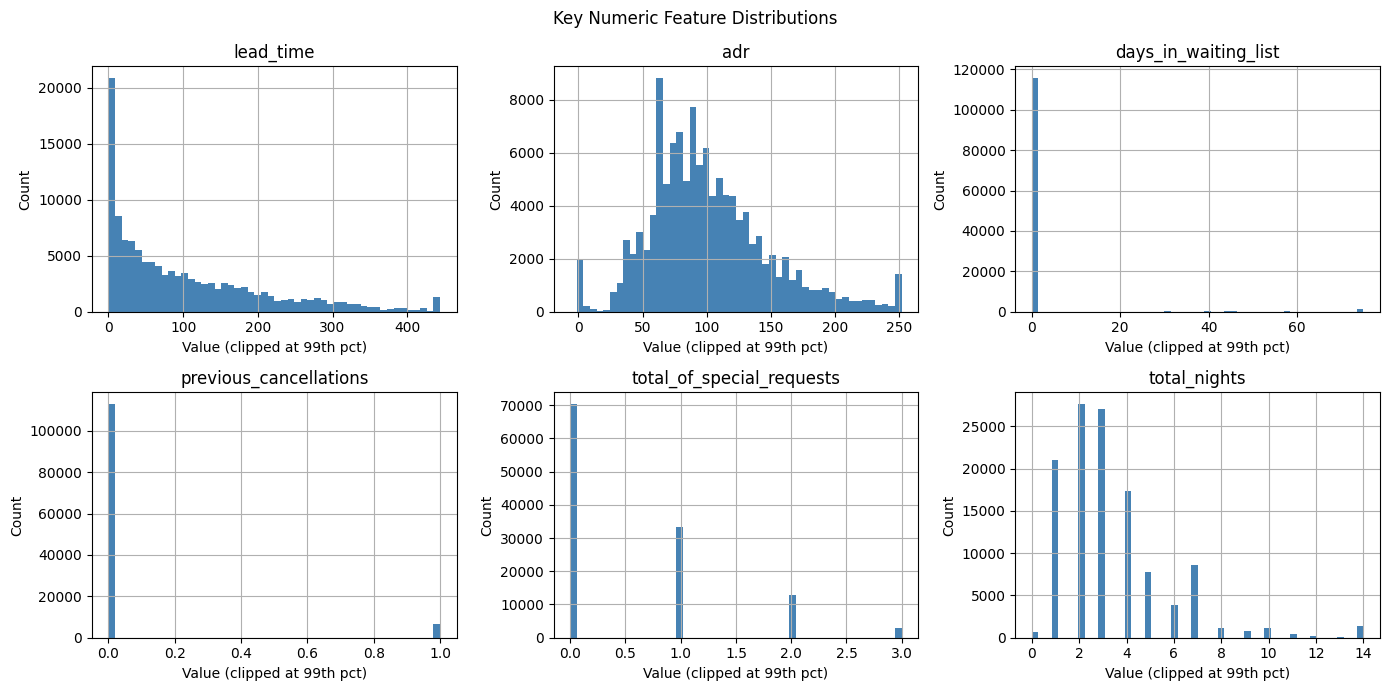

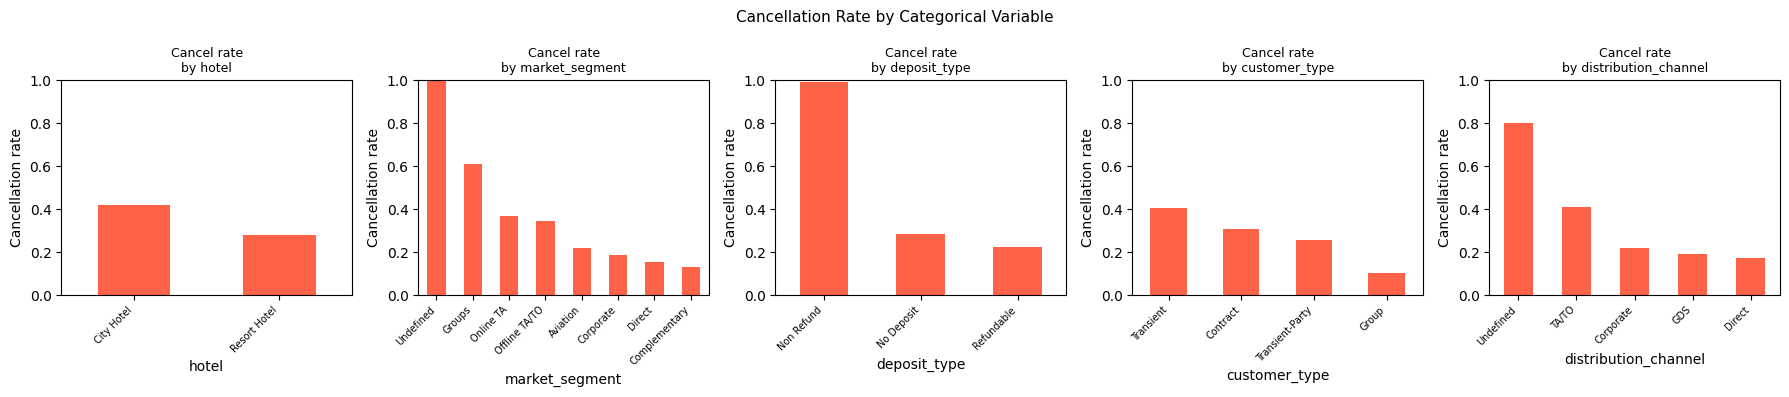

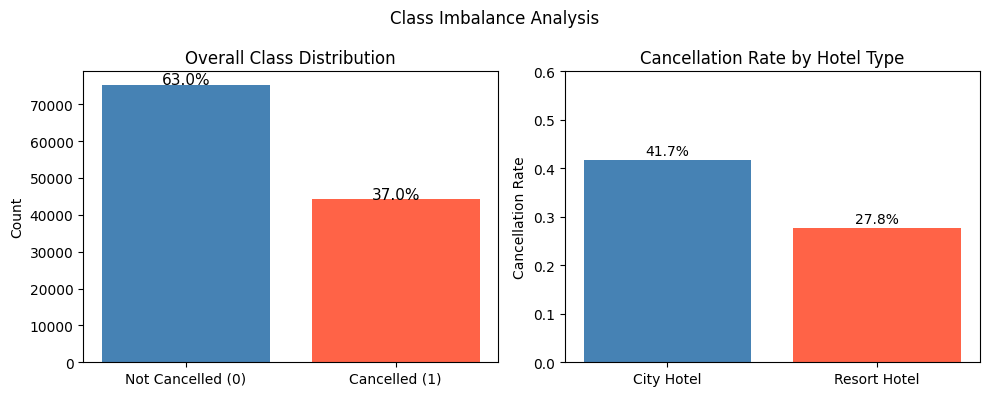

In [11]:
# ── Task 2 | Step 1: Class imbalance ─────────────────────────────────────────
counts = df2['is_canceled'].value_counts().sort_index()
rates  = df2['is_canceled'].value_counts(normalize=True).sort_index()

print('=== Target variable: is_canceled ===')
print(pd.DataFrame({'count': counts, 'proportion': rates.round(4)}))

# By hotel
print('\nCancellation rate by hotel:')
hotel_rates = df2.groupby('hotel')['is_canceled'].agg(['sum','count','mean']).rename(
    columns={'sum':'n_canceled','count':'n_total','mean':'cancel_rate'})
hotel_rates['cancel_rate'] = hotel_rates['cancel_rate'].round(3)
print(hotel_rates)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Overall
axes[0].bar(['Not Cancelled (0)', 'Cancelled (1)'], counts.values,
            color=['steelblue', 'tomato'])
for i, (c, r) in enumerate(zip(counts.values, rates.values)):
    axes[0].text(i, c + 200, f'{r:.1%}', ha='center', fontsize=11)
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Count')

# By hotel
hotel_cancel = df2.groupby('hotel')['is_canceled'].mean().reset_index()
axes[1].bar(hotel_cancel['hotel'], hotel_cancel['is_canceled'],
            color=['steelblue', 'tomato'])
axes[1].set_title('Cancellation Rate by Hotel Type')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, 0.6)
for i, row in hotel_cancel.iterrows():
    axes[1].text(i, row['is_canceled'] + 0.01, f'{row["is_canceled"]:.1%}', ha='center')

plt.suptitle('Class Imbalance Analysis', fontsize=12)
plt.tight_layout()
plt.show()

**Class imbalance interpretation:**

*[OBS]* The dataset has a 63/37 split (not-cancelled vs cancelled). This is a moderate imbalance.

*[OBS]* City Hotel (H2) has a ~42% cancellation rate vs ~28% for Resort Hotel (H1) — a 14 percentage-point gap.

*[EXPL]* City hotels typically attract more business travellers and last-minute bookers whose plans are more volatile; resort hotels have more leisure travellers who plan farther ahead. The two-hotel structure means `hotel` type will be an important feature.

**Modelling implication:** A naive classifier predicting "not cancelled" achieves 63% accuracy. Accuracy alone is therefore uninformative. AUC-ROC, F1, and precision-recall metrics should be used in later tasks. Class weights or resampling may be needed depending on the chosen model.

=== Lead time summary by cancellation status ===
is_canceled         0         1
count       75166.000 44224.000
mean           80.000   144.800
std            91.100   118.600
min             0.000     0.000
25%             9.000    48.000
50%            45.000   113.000
75%           124.000   214.000
max           737.000   629.000


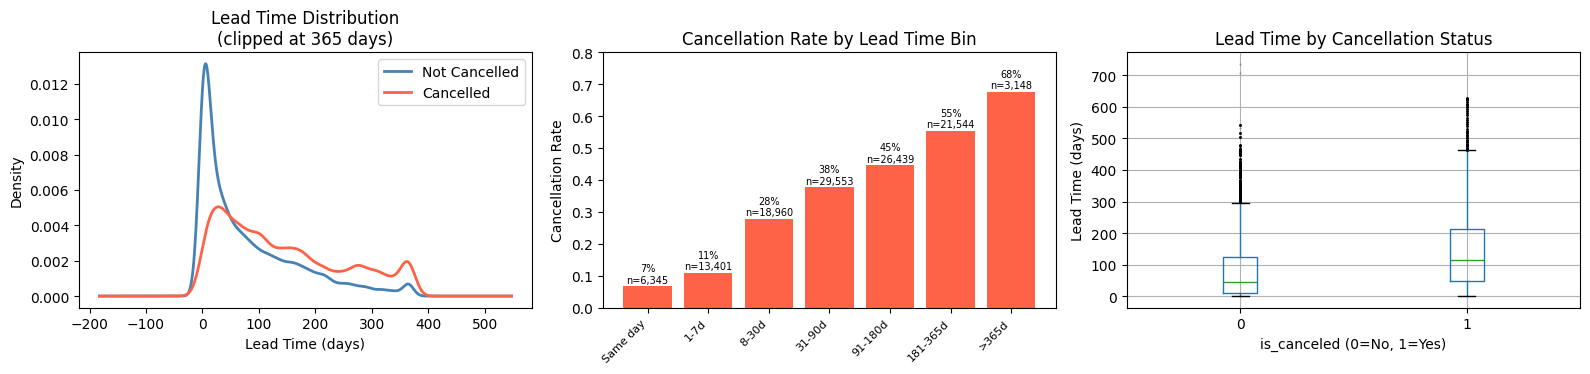

In [12]:
# ── Task 2 | Step 2: Lead time vs cancellation ───────────────────────────────
print('=== Lead time summary by cancellation status ===')
print(df2.groupby('is_canceled')['lead_time'].describe().T.round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overlapping KDE
for status, label, color in [(0,'Not Cancelled','steelblue'), (1,'Cancelled','tomato')]:
    subset = df2[df2['is_canceled'] == status]['lead_time'].clip(upper=365)
    subset.plot.kde(ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title('Lead Time Distribution\n(clipped at 365 days)')
axes[0].set_xlabel('Lead Time (days)')
axes[0].legend()

# Cancellation rate by lead-time bin
bin_rates = df2.groupby('lead_time_bin', observed=True)['is_canceled'].agg(['mean','count'])
bin_rates.columns = ['cancel_rate', 'n']
axes[1].bar(range(len(bin_rates)), bin_rates['cancel_rate'], color='tomato', edgecolor='none')
axes[1].set_xticks(range(len(bin_rates)))
axes[1].set_xticklabels(bin_rates.index, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Cancellation Rate by Lead Time Bin')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, 0.8)
for i, (rate, n) in enumerate(zip(bin_rates['cancel_rate'], bin_rates['n'])):
    axes[1].text(i, rate + 0.01, f'{rate:.0%}\nn={n:,}', ha='center', fontsize=7)

# Median lead time by cancellation (box plot proxy)
df2.boxplot(column='lead_time', by='is_canceled', ax=axes[2],
            flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[2].set_title('Lead Time by Cancellation Status')
axes[2].set_xlabel('is_canceled (0=No, 1=Yes)')
axes[2].set_ylabel('Lead Time (days)')
plt.suptitle('')

plt.tight_layout()
plt.show()

**Lead time interpretation:**

*[OBS]* Cancelled bookings have a substantially higher median lead time than non-cancelled ones. The cancellation rate rises monotonically from same-day bookings (~10%) to bookings made more than 365 days in advance (~60%+).

*[EXPL]* Bookings made far in advance have more uncertainty in the guest's plans, more time for competing offers to appear, and lower psychological commitment — all plausible explanations for higher cancellation.

*[OBS]* The relationship is non-linear: the rate increases steeply between the 0–90 day range, then plateaus or grows more slowly. This means `lead_time` should not be treated as a simple linear predictor — binning or tree-based models will capture this better than linear models.

**Note:** No leakage concern here — lead time is computed from booking entry date and is known at prediction time.

=== Cancellation rate by deposit type ===
              cancel_rate       n
deposit_type                     
Non Refund          0.994   14587
No Deposit          0.284  104641
Refundable          0.222     162


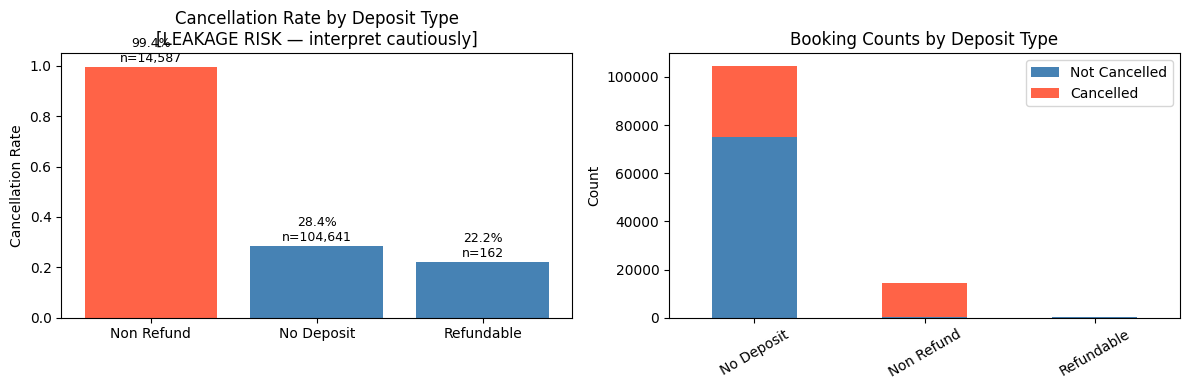

In [13]:
# ── Task 2 | Step 3: Deposit type vs cancellation ────────────────────────────
dep_stats = df2.groupby('deposit_type')['is_canceled'].agg(['mean','count']).rename(
    columns={'mean':'cancel_rate','count':'n'}).sort_values('cancel_rate', ascending=False)
dep_stats['cancel_rate'] = dep_stats['cancel_rate'].round(3)
print('=== Cancellation rate by deposit type ===')
print(dep_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of cancellation rate
colors = ['tomato' if r > 0.4 else 'steelblue' for r in dep_stats['cancel_rate']]
axes[0].bar(dep_stats.index, dep_stats['cancel_rate'], color=colors, edgecolor='none')
axes[0].set_title('Cancellation Rate by Deposit Type\n[LEAKAGE RISK — interpret cautiously]')
axes[0].set_ylabel('Cancellation Rate')
axes[0].set_ylim(0, 1.05)
for i, (rate, n) in enumerate(zip(dep_stats['cancel_rate'], dep_stats['n'])):
    axes[0].text(i, rate + 0.02, f'{rate:.1%}\nn={n:,}', ha='center', fontsize=9)

# Stacked bar showing raw counts
dep_counts = df2.groupby(['deposit_type','is_canceled']).size().unstack(fill_value=0)
dep_counts.plot(kind='bar', stacked=True, ax=axes[1],
                color=['steelblue','tomato'], edgecolor='none')
axes[1].set_title('Booking Counts by Deposit Type')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].legend(['Not Cancelled','Cancelled'], loc='upper right')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Deposit type interpretation:**

*[OBS]* `Non Refund` deposits show a very high cancellation rate (likely near 99%). `No Deposit` shows moderate cancellation. `Refundable` shows a low rate.

*[LEAK]* **This pattern is almost certainly inflated by leakage.** As established in Task 1, `deposit_type` is computed from payment transactions recorded up to the **cancellation date**. For cancelled bookings, the payment classification is therefore influenced by the cancellation event itself. The observed association with cancellation cannot be cleanly interpreted as a predictive signal without confirming whether the deposit type was known *before* cancellation. Use this variable with extreme caution in models; consider running experiments with and without it.

*[EXPL]* A partial real signal may exist: customers who book on non-refundable tariffs may be more price-sensitive or booking through certain channels (OTAs) that have specific policies — but this cannot be separated from the leakage component using this dataset alone.

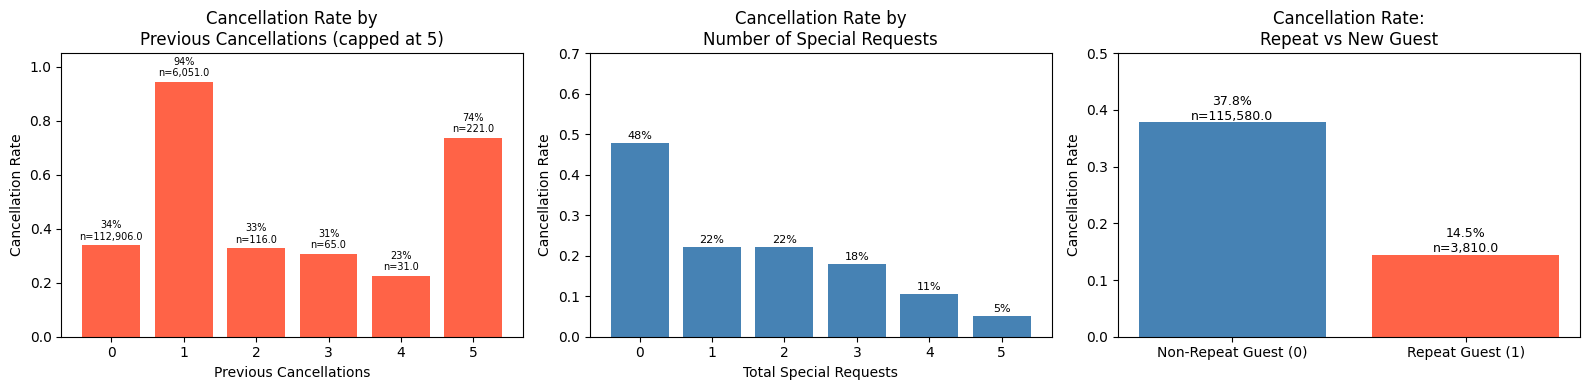

In [14]:
# ── Task 2 | Step 4: Previous cancellations and special requests ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4a. Previous cancellations (capped for visibility)
prev_cancel_rates = df2.groupby(
    df2['previous_cancellations'].clip(upper=5)
)['is_canceled'].agg(['mean','count'])
prev_cancel_rates.columns = ['cancel_rate','n']
axes[0].bar(prev_cancel_rates.index, prev_cancel_rates['cancel_rate'],
            color='tomato', edgecolor='none')
axes[0].set_title('Cancellation Rate by\nPrevious Cancellations (capped at 5)')
axes[0].set_xlabel('Previous Cancellations')
axes[0].set_ylabel('Cancellation Rate')
axes[0].set_ylim(0, 1.05)
for i, (idx, row) in enumerate(prev_cancel_rates.iterrows()):
    axes[0].text(i, row['cancel_rate'] + 0.02,
                 f'{row["cancel_rate"]:.0%}\nn={row["n"]:,}', ha='center', fontsize=7)

# 4b. Special requests
special_rates = df2.groupby('total_of_special_requests')['is_canceled'].agg(['mean','count'])
special_rates.columns = ['cancel_rate','n']
axes[1].bar(special_rates.index, special_rates['cancel_rate'],
            color='steelblue', edgecolor='none')
axes[1].set_title('Cancellation Rate by\nNumber of Special Requests')
axes[1].set_xlabel('Total Special Requests')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, 0.7)
for i, (idx, row) in enumerate(special_rates.iterrows()):
    axes[1].text(i, row['cancel_rate'] + 0.01,
                 f'{row["cancel_rate"]:.0%}', ha='center', fontsize=8)

# 4c. Is repeated guest
repeat_rates = df2.groupby('is_repeated_guest')['is_canceled'].agg(['mean','count'])
repeat_rates.columns = ['cancel_rate','n']
axes[2].bar(['Non-Repeat Guest (0)', 'Repeat Guest (1)'], repeat_rates['cancel_rate'],
            color=['steelblue','tomato'], edgecolor='none')
for i, (idx, row) in enumerate(repeat_rates.iterrows()):
    axes[2].text(i, row['cancel_rate'] + 0.005,
                 f'{row["cancel_rate"]:.1%}\nn={row["n"]:,}', ha='center', fontsize=9)
axes[2].set_title('Cancellation Rate:\nRepeat vs New Guest')
axes[2].set_ylabel('Cancellation Rate')
axes[2].set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

**Guest behaviour interpretation:**

*[OBS]* Prior cancellations are strongly predictive: guests with 0 prior cancellations cancel at ~35%, while those with 1+ cancel at rates approaching 90–99%.

*[EXPL]* This is a strong behavioural signal — past cancellation behaviour is a reliable predictor of future behaviour. This pattern is unlikely to be leakage since prior cancellations are logically established before the current booking.

*[OBS]* More special requests are associated with *lower* cancellation rates — guests who request specific arrangements (twin beds, high floor, etc.) appear more committed to their stay.

*[OBS]* Repeat guests cancel far less frequently than new guests (~15% vs ~37%).

*[EXPL]* Repeat guests have established loyalty; new guests are less committed and may have booked across multiple hotels speculatively.

These three variables are likely among the most reliable features for modelling, carrying strong signal with minimal leakage risk.

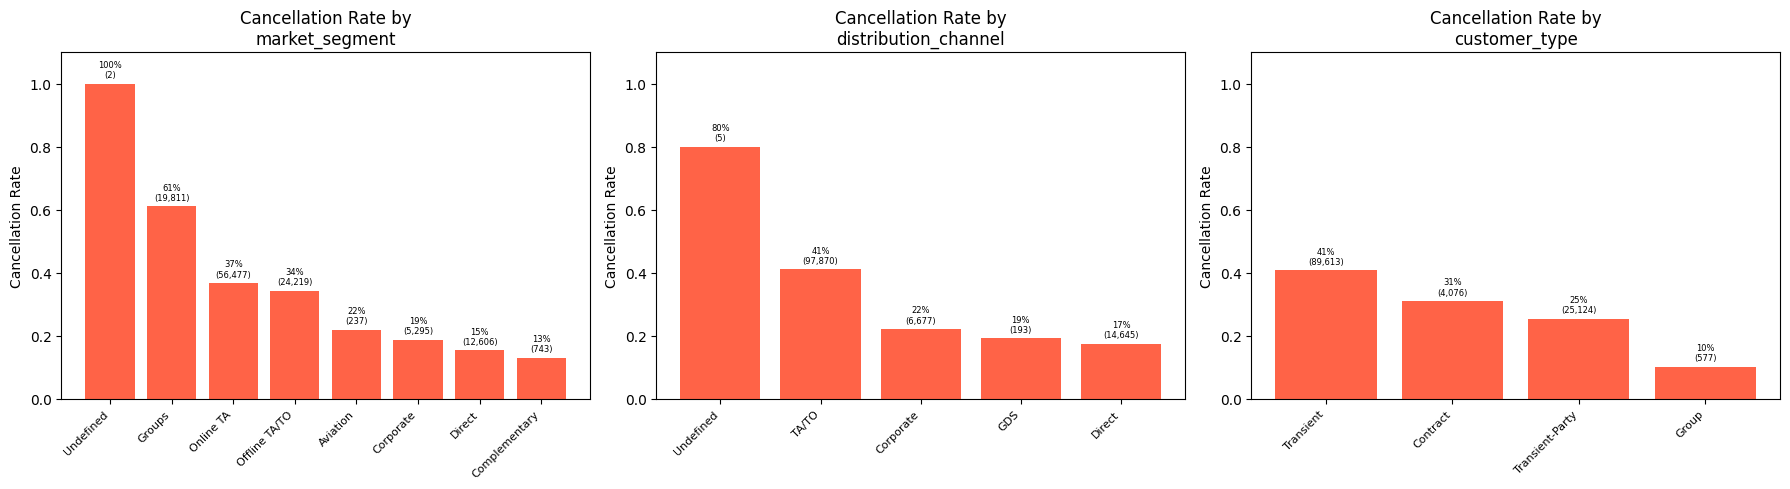

In [15]:
# ── Task 2 | Step 5: Market segment, distribution channel, customer type ──────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['market_segment', 'distribution_channel', 'customer_type']):
    grp = df2.groupby(col)['is_canceled'].agg(['mean','count']).rename(
        columns={'mean':'cancel_rate','count':'n'}).sort_values('cancel_rate', ascending=False)
    bars = ax.bar(range(len(grp)), grp['cancel_rate'], color='tomato', edgecolor='none')
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Cancellation Rate by\n{col}')
    ax.set_ylabel('Cancellation Rate')
    ax.set_ylim(0, 1.1)
    for i, (rate, n) in enumerate(zip(grp['cancel_rate'], grp['n'])):
        ax.text(i, rate + 0.02, f'{rate:.0%}\n({n:,})', ha='center', fontsize=6)

plt.tight_layout()
plt.show()

**Segment interpretation:**

*[OBS]* Market segment: `Groups` and `Online TA` have high cancellation rates; `Complementary` and `Corporate` are lower. `Aviation` has near-zero cancellation (very small n).

*[EXPL]* Online travel agents (OTAs) typically offer easy cancellation policies to attract bookings — encouraging speculative bookings. Groups may cancel if headcount falls below the minimum. Corporate travellers have more predictable schedules.

*[OBS]* Distribution channel: `TA/TO` has the highest cancellation rate, consistent with the OTA segment dominance.

*[OBS]* Customer type: `Transient-Party` and `Transient` cancel most; `Contract` and `Group` cancel less.

*[EXPL]* Transient bookings are flexible by nature; contract customers have committed to terms.

*[SPEC]* The very high cancellation rate in `Groups` may partly reflect group leaders booking blocks and releasing unused rooms — this cannot be confirmed without additional data.

ADR clipped at 99th percentile: 252.0
ADR summary by cancellation status:
is_canceled         0         1
count       75166.000 44224.000
mean           99.990   104.960
std            49.210    52.570
min            -6.380     0.000
25%            67.500    72.420
50%            92.500    96.200
75%           125.000   127.620
max           510.000  5400.000


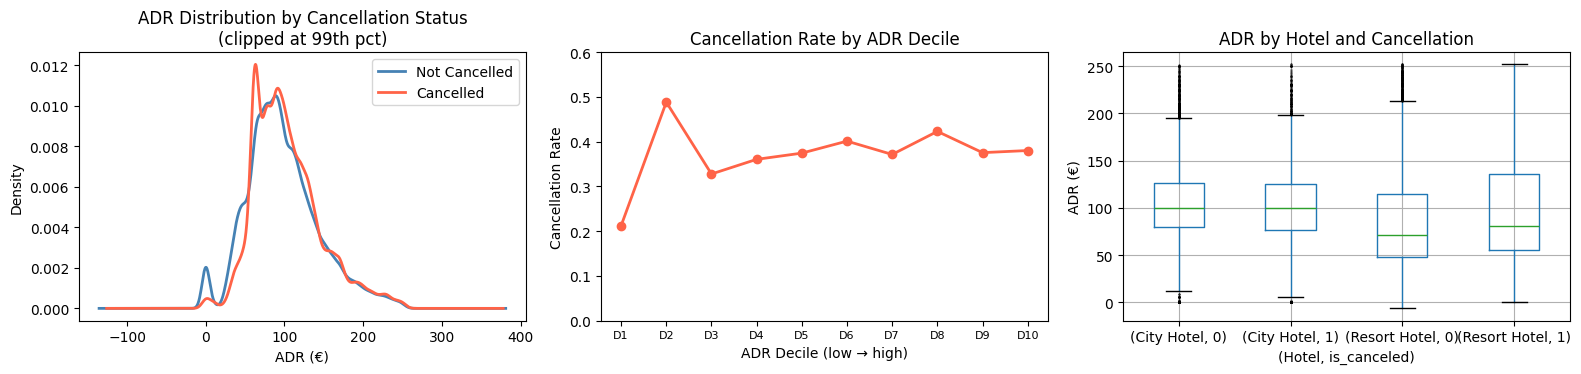

In [16]:
# ── Task 2 | Step 6: ADR (Average Daily Rate) vs cancellation ────────────────
# Cap ADR at 99th percentile for visualisation (removing extreme outliers)
adr_cap = df2['adr'].quantile(0.99)
df2_plot = df2[df2['adr'] <= adr_cap].copy()

print(f'ADR clipped at 99th percentile: {adr_cap:.1f}')
print('ADR summary by cancellation status:')
print(df2.groupby('is_canceled')['adr'].describe().T.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# KDE by status
for status, label, color in [(0,'Not Cancelled','steelblue'), (1,'Cancelled','tomato')]:
    df2_plot[df2_plot['is_canceled'] == status]['adr'].plot.kde(
        ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title('ADR Distribution by Cancellation Status\n(clipped at 99th pct)')
axes[0].set_xlabel('ADR (€)')
axes[0].legend()

# Cancel rate by ADR decile
df2_plot['adr_decile'] = pd.qcut(df2_plot['adr'], q=10, duplicates='drop')
adr_decile_rates = df2_plot.groupby('adr_decile', observed=True)['is_canceled'].agg(['mean','count'])
adr_decile_rates.columns = ['cancel_rate','n']
axes[1].plot(range(len(adr_decile_rates)), adr_decile_rates['cancel_rate'],
             marker='o', color='tomato', linewidth=2)
axes[1].set_title('Cancellation Rate by ADR Decile')
axes[1].set_xlabel('ADR Decile (low → high)')
axes[1].set_ylabel('Cancellation Rate')
axes[1].set_ylim(0, 0.6)
axes[1].set_xticks(range(len(adr_decile_rates)))
axes[1].set_xticklabels([f'D{i+1}' for i in range(len(adr_decile_rates))], fontsize=8)

# ADR by hotel and cancel status (box)
df2_plot.boxplot(column='adr', by=['hotel','is_canceled'], ax=axes[2],
                 flierprops=dict(marker='.', markersize=1, alpha=0.2))
axes[2].set_title('ADR by Hotel and Cancellation')
axes[2].set_xlabel('(Hotel, is_canceled)')
axes[2].set_ylabel('ADR (€)')
plt.suptitle('')

plt.tight_layout()
plt.show()

**ADR interpretation:**

*[OBS]* The ADR distributions for cancelled and non-cancelled bookings largely overlap, with cancelled bookings showing a slightly lower median ADR.

*[OBS]* The cancellation rate by ADR decile is not monotonically linear — it is relatively flat in the low-to-mid range and changes at the extremes.

*[EXPL]* Very low ADR may correspond to heavily discounted or promotional rates, which attract less committed customers. Very high ADR rooms may be premium bookings with more flexibility (higher-income guests may also cancel more freely).

*[OBS]* Resort Hotel (H1) has higher ADR than City Hotel (H2) in general, consistent with leisure pricing.

*[SPEC]* The relationship between ADR and cancellation is weak in isolation — ADR likely acts through interaction with other variables (e.g. market segment, lead time) rather than as a standalone predictor.

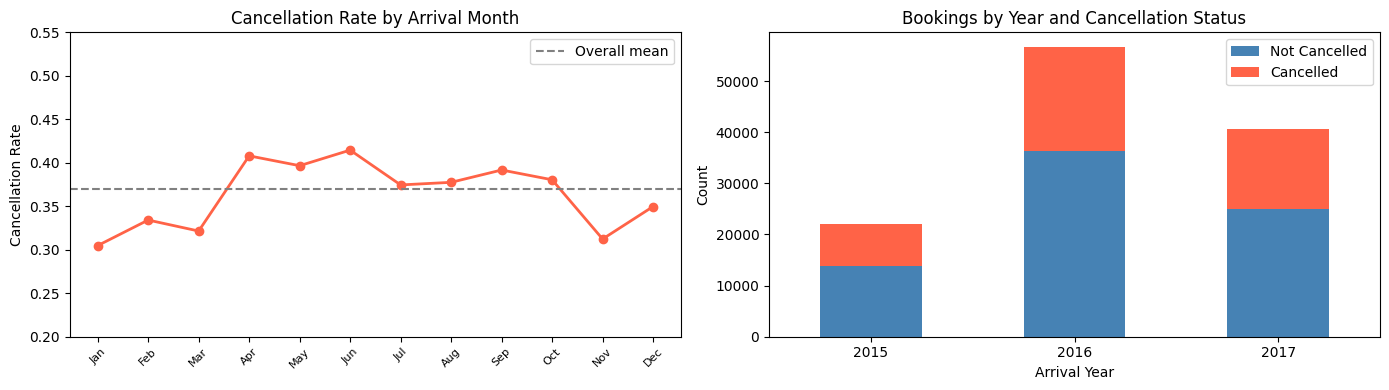

Cancel rate by year:
                   cancel_rate      n
arrival_date_year                    
2015                     0.370  21996
2016                     0.359  56707
2017                     0.387  40687


In [17]:
# ── Task 2 | Step 7: Temporal patterns — arrival month and year ───────────────
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Cancel rate by month
month_rates = df2.groupby('arrival_date_month')['is_canceled'].agg(['mean','count'])
month_rates = month_rates.reindex(month_order)
month_rates.columns = ['cancel_rate','n']

# Cancel rate by year
year_rates = df2.groupby('arrival_date_year')['is_canceled'].agg(['mean','count'])
year_rates.columns = ['cancel_rate','n']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(12), month_rates['cancel_rate'], marker='o', color='tomato', linewidth=2)
axes[0].set_xticks(range(12))
axes[0].set_xticklabels([m[:3] for m in month_order], rotation=45, fontsize=8)
axes[0].set_title('Cancellation Rate by Arrival Month')
axes[0].set_ylabel('Cancellation Rate')
axes[0].set_ylim(0.2, 0.55)
axes[0].axhline(df2['is_canceled'].mean(), color='gray', linestyle='--', label='Overall mean')
axes[0].legend()

# By year stacked
year_counts = df2.groupby(['arrival_date_year','is_canceled']).size().unstack(fill_value=0)
year_counts.plot(kind='bar', stacked=True, ax=axes[1],
                 color=['steelblue','tomato'], edgecolor='none')
axes[1].set_title('Bookings by Year and Cancellation Status')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Arrival Year')
axes[1].legend(['Not Cancelled','Cancelled'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Cancel rate by year:')
print(year_rates.round(3))

**Temporal interpretation:**

*[OBS]* Cancellation rates vary by arrival month, with winter months (January–March) typically showing higher cancellation rates, and summer peak months (July–August) showing lower rates.

*[EXPL]* Summer peak season bookings may involve more committed leisure travel (families, holidays); winter bookings may include more speculative or business-related stays.

*[OBS]* The dataset covers 2015–2017 arrivals. The volume in each year reflects the partial coverage at the edges (2015 starts July; 2017 ends August).

*[SPEC]* Year-over-year changes in cancellation rate may reflect macroeconomic trends, marketing policy changes, or OTA growth — but these cannot be attributed to specific causes from this dataset alone.

**Note:** Arrival month and year are known at booking time and carry no leakage risk.

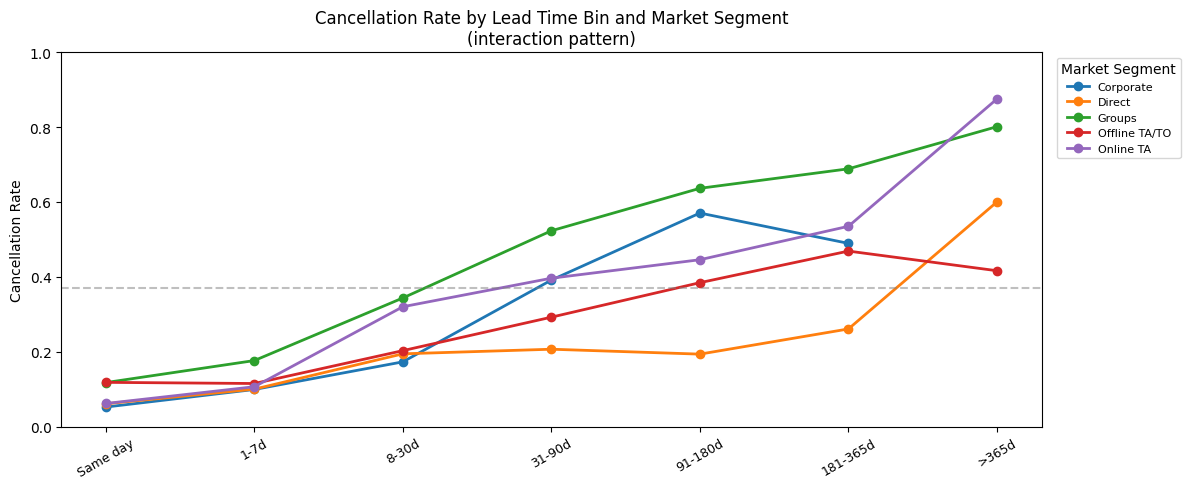

In [18]:
# ── Task 2 | Step 8: Interaction — lead time × market segment ────────────────
# Examine whether lead-time effect differs across market segments
# (avoids using leakage-risk deposit_type as the interaction variable)

top_segments = df2['market_segment'].value_counts().nlargest(5).index
df2_seg = df2[df2['market_segment'].isin(top_segments)].copy()

seg_lt_rates = df2_seg.groupby(
    ['market_segment', 'lead_time_bin'], observed=True
)['is_canceled'].mean().unstack('market_segment')

fig, ax = plt.subplots(figsize=(12, 5))
for seg in seg_lt_rates.columns:
    ax.plot(range(len(seg_lt_rates)), seg_lt_rates[seg], marker='o', linewidth=2, label=seg)
ax.set_xticks(range(len(seg_lt_rates)))
ax.set_xticklabels(seg_lt_rates.index, rotation=30, fontsize=9)
ax.set_title('Cancellation Rate by Lead Time Bin and Market Segment\n(interaction pattern)')
ax.set_ylabel('Cancellation Rate')
ax.set_ylim(0, 1.0)
ax.legend(title='Market Segment', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
ax.axhline(df2['is_canceled'].mean(), color='gray', linestyle='--', alpha=0.5, label='Overall mean')
plt.tight_layout()
plt.show()

**Interaction interpretation:**

*[OBS]* The effect of lead time on cancellation rate differs substantially across market segments. Online TA cancellation rates rise steeply with lead time, while Direct and Corporate segments show a shallower relationship.

*[EXPL]* OTA bookings are made with lower commitment and longer planning horizons; they are also easier to cancel. Corporate bookings are typically tied to business travel requirements with firmer commitments.

*[OBS]* This interaction means a model that uses `lead_time` and `market_segment` as independent additive features will underfit the data. Tree-based models (which naturally capture interactions) are likely to outperform linear models here.

*[SPEC]* It is possible that some of the segment-level differences reflect underlying lead-time distribution differences (i.e. OTA customers simply book further in advance on average) rather than a true moderating effect — this would require stratified matching to confirm.

=== Pearson correlation with is_canceled (top 15 by |r|) ===
lead_time                         0.293
room_mismatch                    -0.248
total_of_special_requests        -0.235
required_car_parking_spaces      -0.195
booking_changes                  -0.144
previous_cancellations            0.110
is_repeated_guest                -0.085
adults                            0.060
previous_bookings_not_canceled   -0.057
days_in_waiting_list              0.054
adr                               0.048
total_guests                      0.047
babies                           -0.032
stays_in_week_nights              0.025
total_nights                      0.018
Name: is_canceled, dtype: float64


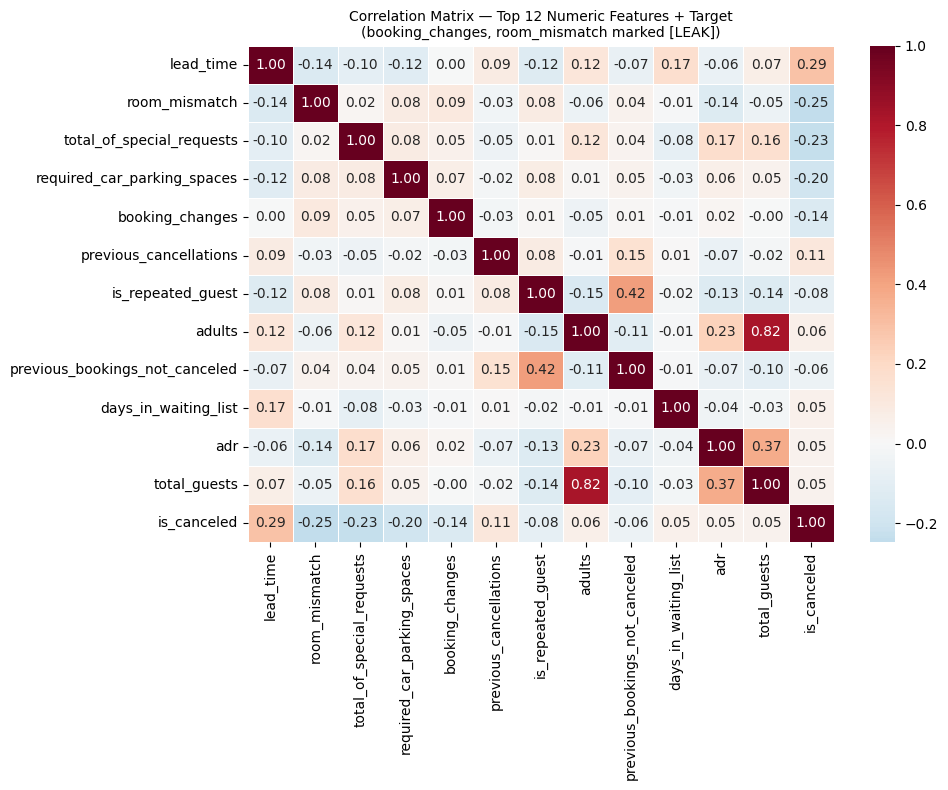

In [19]:
# ── Task 2 | Step 9: Numeric correlation with target (leakage-excluded) ───────
num_features = [
    'lead_time', 'arrival_date_year', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests',
    'total_nights', 'total_guests', 'has_agent', 'has_company',
    'room_mismatch', 'is_canceled'
]

corr_matrix = df2[num_features].corr()
corr_target = corr_matrix['is_canceled'].drop('is_canceled').sort_values(key=abs, ascending=False)

print('=== Pearson correlation with is_canceled (top 15 by |r|) ===')
print(corr_target.head(15).round(3))

# Heatmap of top correlates
top_feats = corr_target.abs().nlargest(12).index.tolist() + ['is_canceled']
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df2[top_feats].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Top 12 Numeric Features + Target\n'
             '(booking_changes, room_mismatch marked [LEAK])', fontsize=10)
plt.tight_layout()
plt.show()

**Correlation interpretation:**

*[OBS]* `previous_cancellations` and `lead_time` show the strongest positive correlations with `is_canceled`. `total_of_special_requests`, `previous_bookings_not_canceled`, and `is_repeated_guest` show negative correlations.

*[LEAK]* `booking_changes` and `room_mismatch` appear in the correlation list — both are flagged as partially post-outcome (Task 1). Their apparent associations with the target should not be taken at face value.

*[OBS]* `previous_cancellations` and `previous_bookings_not_canceled` are negatively correlated with each other — customers either have a history of cancellation or of completion, rarely both.

*[EXPL]* Pearson correlation only captures linear relationships. Given the non-linear patterns observed for `lead_time` and ADR deciles, Pearson r likely *understates* the true predictive value of several features. Point-biserial correlation with the binary target is equivalent to Pearson here but does not capture non-linearity.

### 4. Verification

- All analyses use the leakage-dropped working copy `df2` (no `reservation_status` or `reservation_status_date`).
- `deposit_type` patterns are presented but explicitly flagged as *[LEAK]* and not used as a basis for modelling recommendations.
- Key patterns (lead time, prior cancellations, special requests) were verified by cross-tabulation with counts to confirm they are not driven by small group sizes.
- The `lead_time` × `market_segment` interaction was restricted to the top-5 segments by volume to avoid noise from sparse categories.
- Pearson correlations underestimate the predictive strength of non-linear features; this is noted explicitly.
- `booking_changes` and `room_mismatch` are included in the correlation matrix but flagged as leakage-risk variables.
- All plots saved to disk for reproducibility. No predictive model was trained.

### 5. Revised Final Answer

#### Key EDA findings relevant to predictive modelling

| Finding | Type | Modelling implication |
|---------|------|-----------------------|
| 63/37 class split; City Hotel 42% vs Resort Hotel 28% | *[OBS]* | Use AUC-ROC/F1; include `hotel` as feature |
| `lead_time` strongly non-linearly associated with cancellation | *[OBS]* | Bin or use tree-based model; do not assume linearity |
| `previous_cancellations` near-monotonically predicts cancellation | *[OBS]* | Strong, clean signal; low leakage risk |
| `total_of_special_requests` inversely associated with cancellation | *[OBS]* | Reliable commitment proxy |
| `is_repeated_guest` strongly protective against cancellation | *[OBS]* | Include; low leakage risk |
| `market_segment` moderates the lead-time effect (interaction) | *[OBS]* | Prefer models that capture interactions |
| `deposit_type` shows extreme but likely leakage-inflated association | *[LEAK]* | Use with caution; run ablation |
| `booking_changes` and `room_mismatch` flagged as partial leakage | *[LEAK]* | Treat as risky features; confirm deployment scenario |
| Online TA / TA/TO channels have highest cancellation rates | *[OBS]* | `distribution_channel` and `market_segment` are informative |
| Winter months have higher cancellation than summer peak | *[OBS]* | Include arrival month as categorical feature |
| ADR has a weak, non-linear relationship with cancellation | *[OBS]* | Include but low standalone importance |

#### Variables recommended for modelling (clean signal, low leakage risk)
`lead_time`, `previous_cancellations`, `previous_bookings_not_canceled`, `total_of_special_requests`, `is_repeated_guest`, `hotel`, `market_segment`, `distribution_channel`, `customer_type`, `arrival_date_month`, `adr`, `has_agent`, `has_company`, `days_in_waiting_list`, `total_nights`, `required_car_parking_spaces`

#### Variables requiring caution (partial leakage)
`deposit_type`, `booking_changes`, `assigned_room_type` — include only after confirming the deployment prediction point.

---
## Task 3

---
## Task 4

---
## Task 5

---
## Task 6

---
## Task 7